<a href="https://colab.research.google.com/github/Ala-Mohamed/Churn-Analysis/blob/main/prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn joblib

In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix

from sklearn.preprocessing import LabelEncoder

import joblib

# Define the path to the Excel file

file_path = r"/content/prediction_data.xlsx"



# Define the sheet name to read data from
sheet_name = 'Sheet2'



# Read the data from the specified sheet into a pandas DataFrame
data = pd.read_excel(file_path, sheet_name=sheet_name)



# Display the first few rows of the fetched data
print(data.head())

  Customer_ID  Gender  Age Married          State  Number_of_Referrals  \
0   54407-WES    Male   59     Yes    West Bengal                    5   
1   46106-UTT  Female   33      No  Uttar Pradesh                   13   
2   68494-MAH  Female   34      No    Maharashtra                   11   
3   74683-TEL  Female   68      No      Telangana                    3   
4   28544-TAM  Female   80      No     Tamil Nadu                    3   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                29     Deal 5           Yes            Yes  ...   
1                 5     Deal 3           Yes             No  ...   
2                27     Deal 4           Yes            Yes  ...   
3                 1     Deal 1           Yes            Yes  ...   
4                 8        NaN           Yes             No  ...   

  Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0   Mailed Check      62.049999     62.049999           0.0   
1    Credit Card    

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6007 entries, 0 to 6006
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6007 non-null   object 
 1   Gender                       6007 non-null   object 
 2   Age                          6007 non-null   int64  
 3   Married                      6007 non-null   object 
 4   State                        6007 non-null   object 
 5   Number_of_Referrals          6007 non-null   int64  
 6   Tenure_in_Months             6007 non-null   int64  
 7   Value_Deal                   2710 non-null   object 
 8   Phone_Service                6007 non-null   object 
 9   Multiple_Lines               6007 non-null   object 
 10  Internet_Service             6007 non-null   object 
 11  Internet_Type                4784 non-null   object 
 12  Online_Security              6007 non-null   object 
 13  Online_Backup     

In [10]:
# Drop columns that won't be used for prediction
data = data.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason'], axis=1)



# List of columns to be label encoded

columns_to_encode = [

    'Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',

    'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',

    'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies',

    'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',

    'Payment_Method'

]



# Encode categorical variables except the target variable

label_encoders = {}

for column in columns_to_encode:

    label_encoders[column] = LabelEncoder()

    data[column] = label_encoders[column].fit_transform(data[column])



# Manually encode the target variable 'Customer_Status'

data['Customer_Status'] = data['Customer_Status'].map({'Stayed': 0, 'Churned': 1})



# Split data into features and target

X = data.drop('Customer_Status', axis=1)

y = data['Customer_Status']



# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Confusion Matrix:
[[802  60]
 [110 230]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       862
           1       0.79      0.68      0.73       340

    accuracy                           0.86      1202
   macro avg       0.84      0.80      0.82      1202
weighted avg       0.85      0.86      0.85      1202



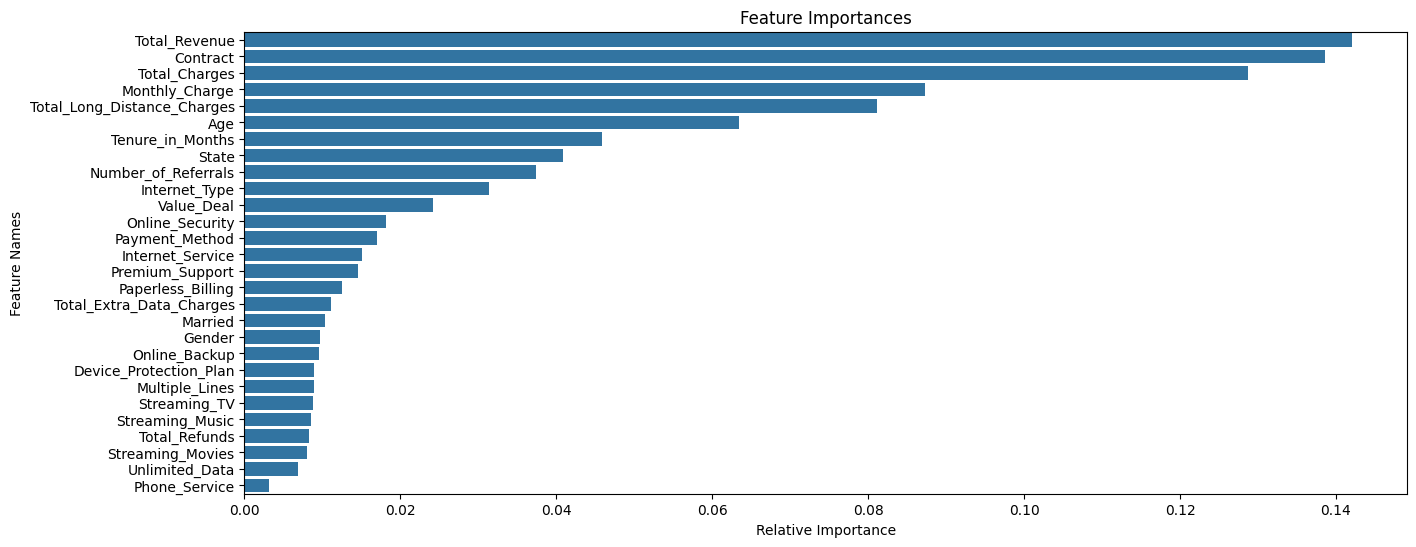

  Customer_ID  Gender  Age Married          State  Number_of_Referrals  \
0   74033-ASS  Female   45     Yes          Assam                   15   
1   46190-GUJ    Male   27     Yes        Gujarat                    0   
2   39764-UTT  Female   39     Yes  Uttar Pradesh                    5   
3   53449-MAH  Female   52      No    Maharashtra                    8   
4   61025-MAH  Female   45      No    Maharashtra                    4   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                20        NaN            No             No  ...   
1                36     Deal 5           Yes             No  ...   
2                14        NaN           Yes             No  ...   
3                17        NaN           Yes             No  ...   
4                16     Deal 5           Yes             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0  Bank Withdrawal      25.250000     25.250000           0.0   
1     Mailed Che

In [12]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)



# Train the model

rf_model.fit(X_train, y_train)



# Evaluate Model

# Make predictions

y_pred = rf_model.predict(X_test)



# Evaluate the model

print("Confusion Matrix:")

print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")

print(classification_report(y_test, y_pred))



# Feature Selection using Feature Importance

importances = rf_model.feature_importances_

indices = np.argsort(importances)[::-1]



# Plot the feature importances

plt.figure(figsize=(15, 6))

sns.barplot(x=importances[indices], y=X.columns[indices])

plt.title('Feature Importances')

plt.xlabel('Relative Importance')

plt.ylabel('Feature Names')

plt.show()
# Use Model for Prediction on New Data

# Define the path to the Joiner Data Excel file
file_path = r"/content/prediction_data.xlsx"



# Define the sheet name to read data from

sheet_name = 'Sheet3'



# Read the data from the specified sheet into a pandas DataFrame

new_data = pd.read_excel(file_path, sheet_name=sheet_name)



# Display the first few rows of the fetched data

print(new_data.head())



# Retain the original DataFrame to preserve unencoded columns

original_data = new_data.copy()



# Retain the Customer_ID column

customer_ids = new_data['Customer_ID']



# Drop columns that won't be used for prediction in the encoded DataFrame

new_data = new_data.drop(['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'], axis=1)



# Encode categorical variables using the saved label encoders

for column in new_data.select_dtypes(include=['object']).columns:

    new_data[column] = label_encoders[column].transform(new_data[column])



# Make predictions

new_predictions = rf_model.predict(new_data)



# Add predictions to the original DataFrame

original_data['Customer_Status_Predicted'] = new_predictions



# Filter the DataFrame to include only records predicted as "Churned"

original_data = original_data[original_data['Customer_Status_Predicted'] == 1]



# Save the results

original_data.to_csv(r"Predictions.csv", index=False)